# Análise dos Dados de Ondas Retirados do Osciloscópio
Nota nos exemplos: E5 (Mi) - 12ª casa da 1ª corda da guitarra.  
Acorde tocado: D (Ré) - Formato padrão

---

## 0. Definição da função que processará os dados

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq
from scipy.signal import find_peaks, windows, hilbert, correlate

def analisar_sinal(arquivo_csv, titulo="Análise Detalhada", freq_zoom=2000):

    # ===============================
    # 1. CARREGAMENTO
    # ===============================
    df = pd.read_csv(arquivo_csv)
    tempo = df.iloc[:,0].values
    sinal_in_raw = df.iloc[:,1].values
    sinal_out_raw = df.iloc[:,2].values

    sinal_in = sinal_in_raw - np.mean(sinal_in_raw)
    sinal_out = sinal_out_raw - np.mean(sinal_out_raw)

    dt = tempo[1] - tempo[0]
    fs = 1 / dt
    N = len(tempo)

    print(f"\n{'='*20} {titulo} {'='*20}")
    print(f"fs = {fs/1000:.1f} kHz | N = {N}")

    # ===============================
    # 2. FFT + FUNDAMENTAL
    # ===============================
    janela = windows.hann(N)

    yf_in = rfft(sinal_in * janela)
    yf_out = rfft(sinal_out * janela)

    xf = rfftfreq(N, dt)

    mag_in = np.abs(yf_in)
    mag_out = np.abs(yf_out)

    # Detecta picos acima de 40Hz
    peaks, _ = find_peaks(mag_in, distance=10)
    valid = [i for i in peaks if xf[i] > 40]

    if len(valid) == 0:
        print("Fundamental não detectada.")
        return

    idx_fund = valid[np.argmax(mag_in[valid])]
    f0 = xf[idx_fund]

    # ===============================
    # 3. LATÊNCIA POR FASE
    # ===============================
    def calcular_latencia_precisa(sinal_in, sinal_out, fs):
        """
        Calcula a latência de áudio com precisão de sub-amostra,
        combinando Correlação Cruzada (para achar o ciclo) e Fase (para ajuste fino).
        """
        N = len(sinal_in)
        dt = 1/fs
        
        # 1. CORRELAÇÃO CRUZADA (Acha o atraso "grosso" em ms)
        # Isso resolve o problema de saber "quantas voltas" a fase deu.
        corr = correlate(sinal_out, sinal_in, mode='full')
        lag = np.argmax(corr) - (N - 1)
        delay_time_ms = lag * dt * 1000
        
        # Se o delay for negativo (erro de medição), força zero
        if delay_time_ms < 0: delay_time_ms = 0
        
        # 2. ANÁLISE ESPECTRAL (Acha a fundamental f0)
        # Aplica janela de Hanning para reduzir vazamento espectral (ruído)
        janela = windows.hann(N)
        yf_in = rfft(sinal_in * janela)
        yf_out = rfft(sinal_out * janela)
        xf = rfftfreq(N, dt)
        
        # Acha o pico da fundamental (ignora DC < 20Hz)
        idx_start = int(20 / (fs/N)) 
        mag_in = np.abs(yf_in)
        idx_fund = np.argmax(mag_in[idx_start:]) + idx_start
        f0 = xf[idx_fund]
        periodo_ms = (1/f0) * 1000
        
        # 3. CÁLCULO DE FASE (Ajuste Fino)
        phase_in = np.angle(yf_in[idx_fund])
        phase_out = np.angle(yf_out[idx_fund])
        
        # Diferença de fase (-pi a +pi)
        delta_phase = phase_in - phase_out
        delta_phase = np.arctan2(np.sin(delta_phase), np.cos(delta_phase))
        
        # Converte para tempo (fração do ciclo)
        delay_phase_ms = (delta_phase / (2 * np.pi)) * periodo_ms
        
        # Normaliza para positivo
        if delay_phase_ms < 0: delay_phase_ms += periodo_ms
        
        # 4. FUSÃO (O Pulo do Gato)
        # Usa o delay de tempo para saber quantos ciclos inteiros (N) passaram
        # E usa o delay de fase para a precisão decimal
        num_ciclos = round(delay_time_ms / periodo_ms)
        latencia_final_ms = (num_ciclos * periodo_ms) + delay_phase_ms
        
        # Fallback: Se a correlação e a fase discordarem muito (> 1/2 ciclo),
        # confie na correlação (pois em distorção pesada a fase fica caótica).
        if abs(latencia_final_ms - delay_time_ms) > (periodo_ms / 2):
            latencia_final_ms = delay_time_ms

        return latencia_final_ms, f0

    # --- COMO USAR ---
    # Exemplo dentro da sua função de análise:
    delay_ms, freq = calcular_latencia_precisa(sinal_in, sinal_out, fs)

    # ===============================
    # 4. THD (Distorção Harmônica Total)
    # ===============================
    harmonics = []
    for k in range(2, 6):  # 2ª até 5ª harmônica
        target = f0 * k
        idx = np.argmin(np.abs(xf - target))
        harmonics.append(mag_out[idx])

    fundamental_mag = mag_out[idx_fund]
    thd = np.sqrt(np.sum(np.array(harmonics)**2)) / fundamental_mag
    thd_percent = thd * 100

    # ===============================
    # 5. ENVELOPE (para delay/reverb)
    # ===============================
    analytic = hilbert(sinal_out)
    envelope = np.abs(analytic)

    # Tempo de decaimento (aprox)
    peak_env = np.max(envelope)
    threshold = peak_env * 0.1
    decay_idx = np.where(envelope < threshold)[0]
    if len(decay_idx) > 0:
        decay_time = tempo[decay_idx[0]]
    else:
        decay_time = 0

    # ===============================
    # 6. RMS E GANHO
    # ===============================
    rms_in = np.sqrt(np.mean(sinal_in**2))
    rms_out = np.sqrt(np.mean(sinal_out**2))
    gain_db = 20 * np.log10(rms_out / rms_in) if rms_in > 0 else 0

    # ===============================
    # 7. RELATÓRIO
    # ===============================
    print("MÉTRICAS:")
    print(f"Frequência Fundamental: {f0:.2f} Hz")
    print(f"Ganho: {gain_db:.2f} dB")
    print(f"Ganho Linear: {(10**(gain_db/20))*100:.1f}%")
    print(f"Latência (por fase): {delay_ms:.3f} ms")
    print(f"THD: {thd_percent:.2f} %")
    print(f"Tempo de decaimento (~ -20dB): {decay_time*1000:.2f} ms")
    print("-"*60)

    # ===============================
    # 8. GRÁFICOS
    # ===============================
    fig, ax = plt.subplots(3, 1, figsize=(12, 12))

    # Tempo
    ax[0].plot(tempo*1000, sinal_in, label="Input", color='orange', alpha=0.6)
    ax[0].plot(tempo*1000, sinal_out, label="Output", color='blue', alpha=0.8)
    ax[0].set_title(f"Tempo | Latência (fase): {delay_ms:.3f} ms")
    ax[0].set_xlabel("Tempo (ms)")
    ax[0].legend()
    ax[0].grid(True)

    # FFT
    mask = (xf > 20) & (xf < freq_zoom)
    ax[1].plot(xf[mask], 20*np.log10(mag_in[mask]+1e-12), color='orange', label="Input")
    ax[1].plot(xf[mask], 20*np.log10(mag_out[mask]+1e-12), color='blue', label="Output")
    ax[1].axvline(f0, color="red", linestyle="--", label=f"F0 = {f0:.1f}Hz")
    ax[1].set_title("Espectro")
    ax[1].set_xlabel("Hz")
    ax[1].set_ylabel("dB")
    ax[1].legend()
    ax[1].grid(True)

    # Envelope
    ax[2].plot(tempo*1000, envelope)
    ax[2].set_title("Envelope (útil para Delay/Reverb)")
    ax[2].set_xlabel("Tempo (ms)")
    ax[2].grid(True)

    plt.tight_layout()
    plt.show()


## Métricas Geradas pela Análise

- **Frequência Fundamental (Hz)**: Frequência dominante do sinal de entrada, correspondente à nota tocada.
- **Ganho (dB)**: Diferença de nível RMS entre saída e entrada, indicando amplificação ou atenuação total do sistema.
- **Latência por Fase (ms)**: Atraso temporal calculado a partir da diferença de fase da frequência fundamental entre entrada e saída.
- **THD (%)**: Percentual de Distorção Harmônica Total, medindo quanto de conteúdo harmônico adicional foi gerado pelo sistema.
- **Tempo de Decaimento (ms)**: Tempo aproximado para o envelope do sinal cair cerca de 20 dB após o pico, relacionado a sustain, delay ou reverb.
- **Espectro (FFT)**: Distribuição de energia do sinal no domínio da frequência, mostrando fundamental e harmônicos.
- **Envelope do Sinal**: Curva da amplitude instantânea ao longo do tempo, útil para analisar sustain, repetições e cauda de reverb.
- **Domínio do Tempo**: Forma de onda original no tempo, permitindo visualizar distorção, clipping e atraso entre sinais.


## 1. Nota Limpa
<img src="Processing/NotaLimpa0.png" width=40%>



==================== Nota Limpa ====================
fs = 200.0 kHz | N = 1000
MÉTRICAS:
Frequência Fundamental: 600.00 Hz
Ganho: 11.30 dB
Ganho Linear: 367.1%
Latência (por fase): 0.659 ms
THD: 36.52 %
Tempo de decaimento (~ -20dB): 0.72 ms
------------------------------------------------------------


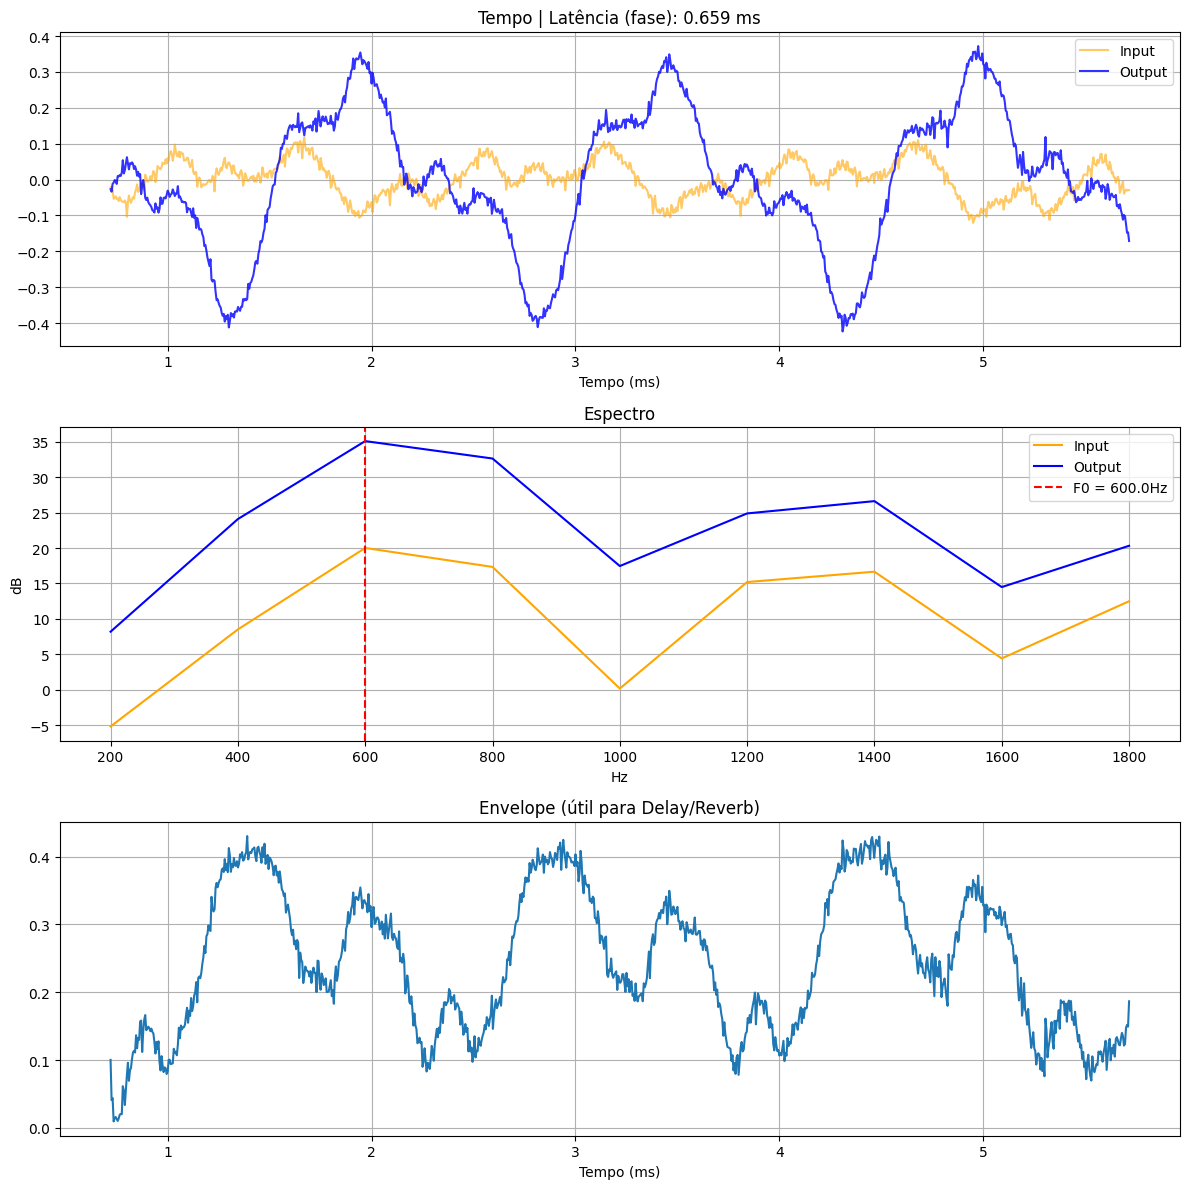

In [32]:
analisar_sinal('Processing/NotaLimpa0.csv', 'Nota Limpa')

## 2. Nota com Delay
<img src='Processing/NotaDelay0.png' width=40%>


==================== Nota com Delay ====================
fs = 200.0 kHz | N = 1000
MÉTRICAS:
Frequência Fundamental: 600.00 Hz
Ganho: 12.54 dB
Ganho Linear: 423.8%
Latência (por fase): 0.609 ms
THD: 14.59 %
Tempo de decaimento (~ -20dB): 0.73 ms
------------------------------------------------------------


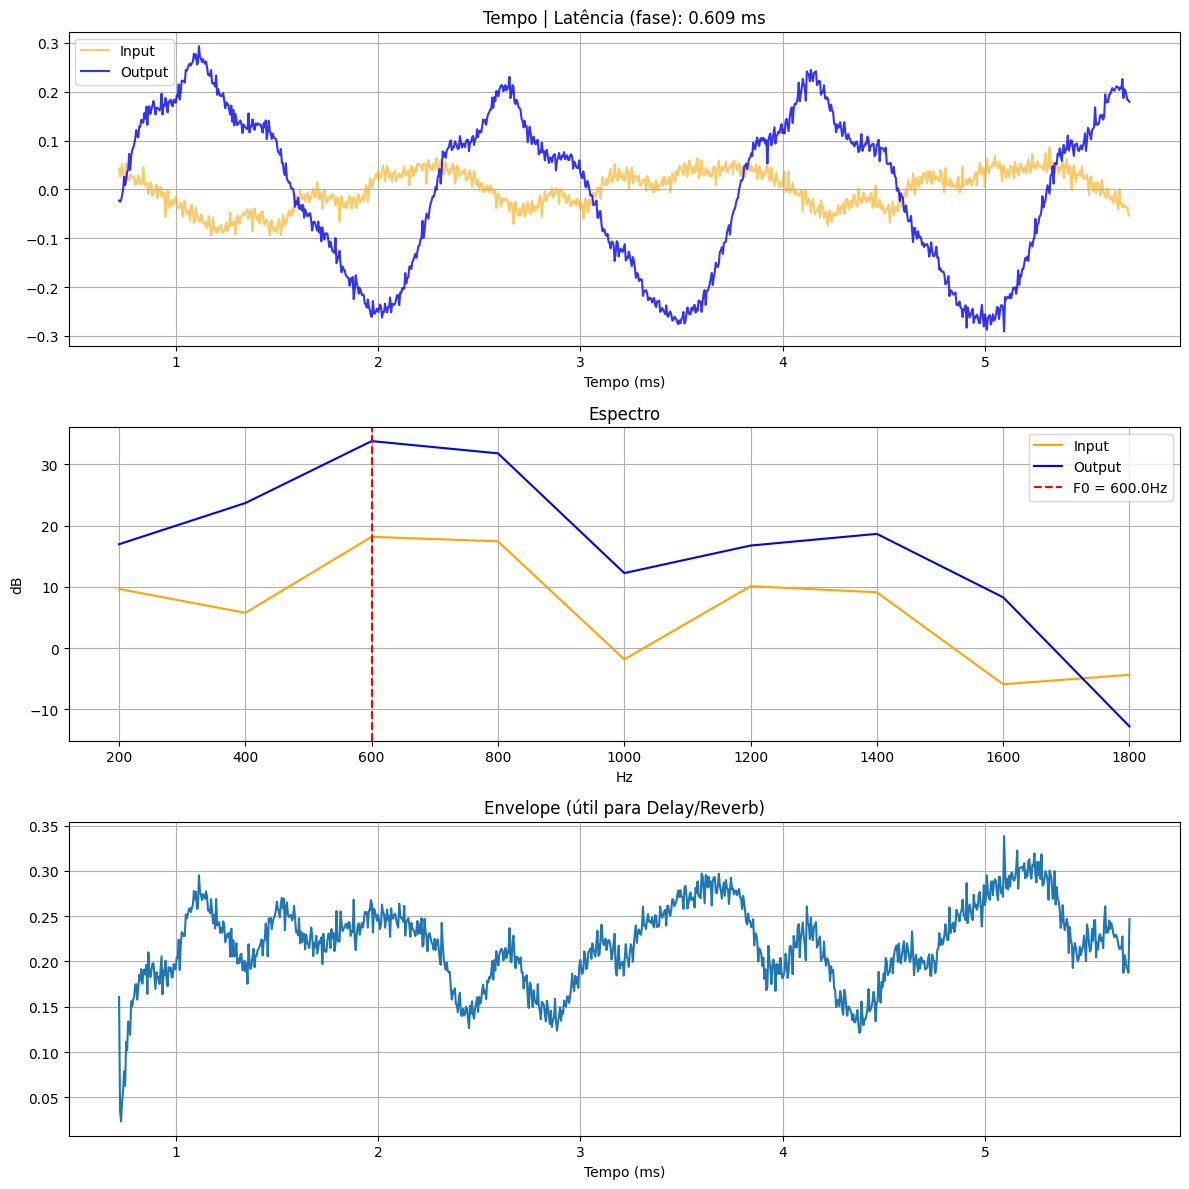

In [33]:
analisar_sinal('Processing/NotaDelay0.csv', 'Nota com Delay')

## 3. Nota com Reverb
<img src='Processing/NotaReverb0.png' width=40%>


==================== Nota com Reverb ====================
fs = 200.0 kHz | N = 1000
MÉTRICAS:
Frequência Fundamental: 600.00 Hz
Ganho: 13.60 dB
Ganho Linear: 478.8%
Latência (por fase): 0.662 ms
THD: 29.70 %
Tempo de decaimento (~ -20dB): 0.00 ms
------------------------------------------------------------


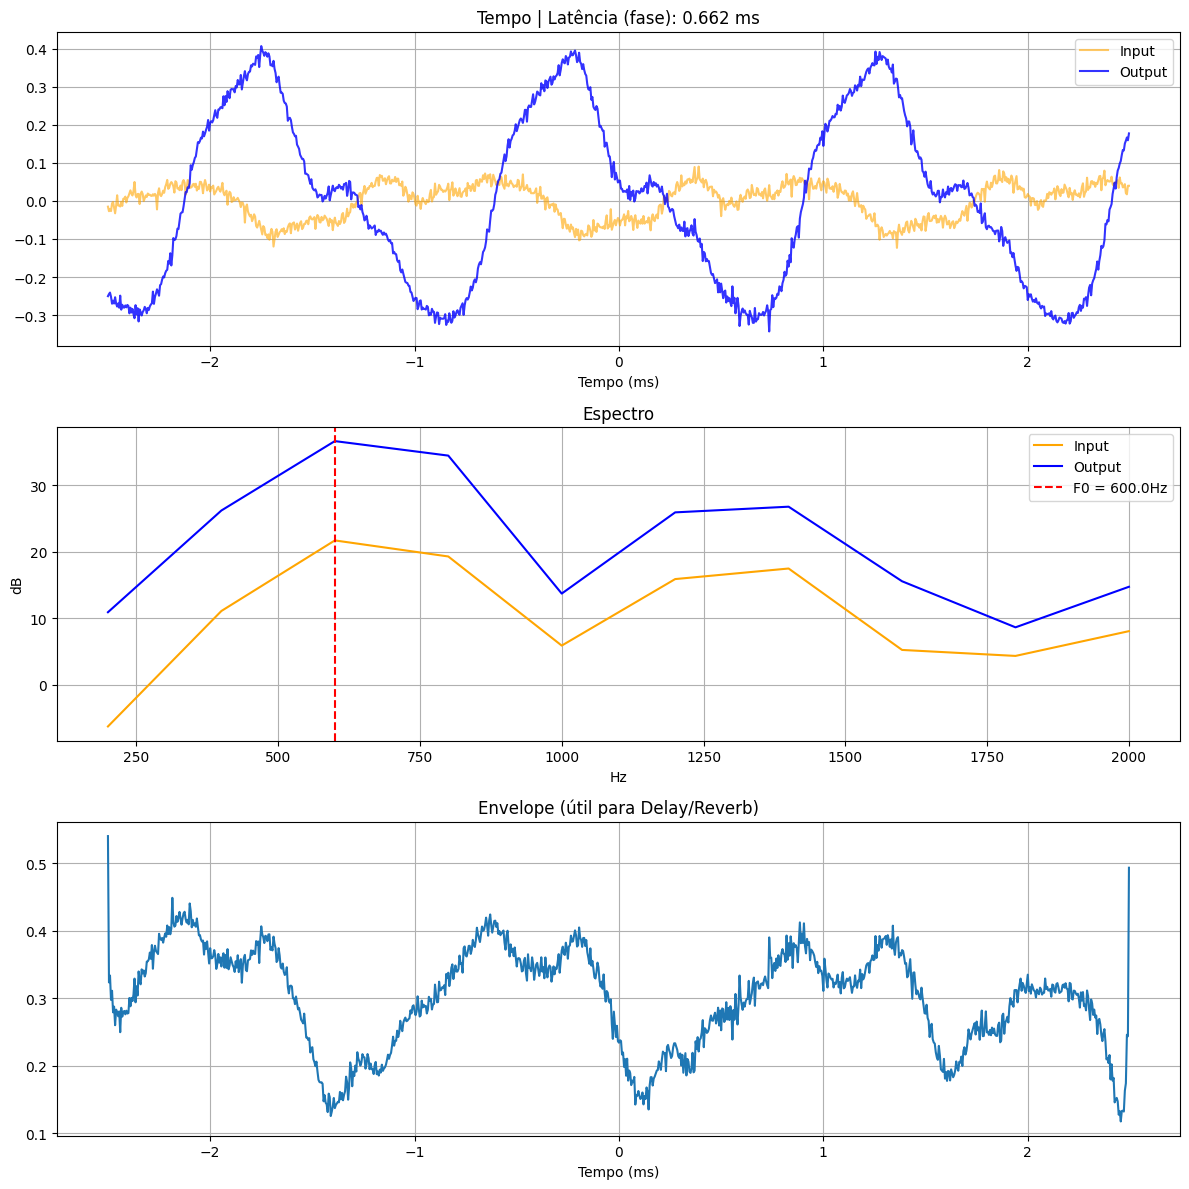

In [34]:
analisar_sinal('Processing/NotaReverb0.csv', 'Nota com Reverb')

## 4. Nota com Drive
<img src='Processing/NotaDrive0.png' width=40%>  
  
**Detalhe: Drive aumenta muito a amplitude, por isso, escala vertical aumentou**


==================== Nota com Drive ====================
fs = 200.0 kHz | N = 1000
MÉTRICAS:
Frequência Fundamental: 600.00 Hz
Ganho: 25.44 dB
Ganho Linear: 1870.0%
Latência (por fase): 0.633 ms
THD: 12.99 %
Tempo de decaimento (~ -20dB): 0.00 ms
------------------------------------------------------------


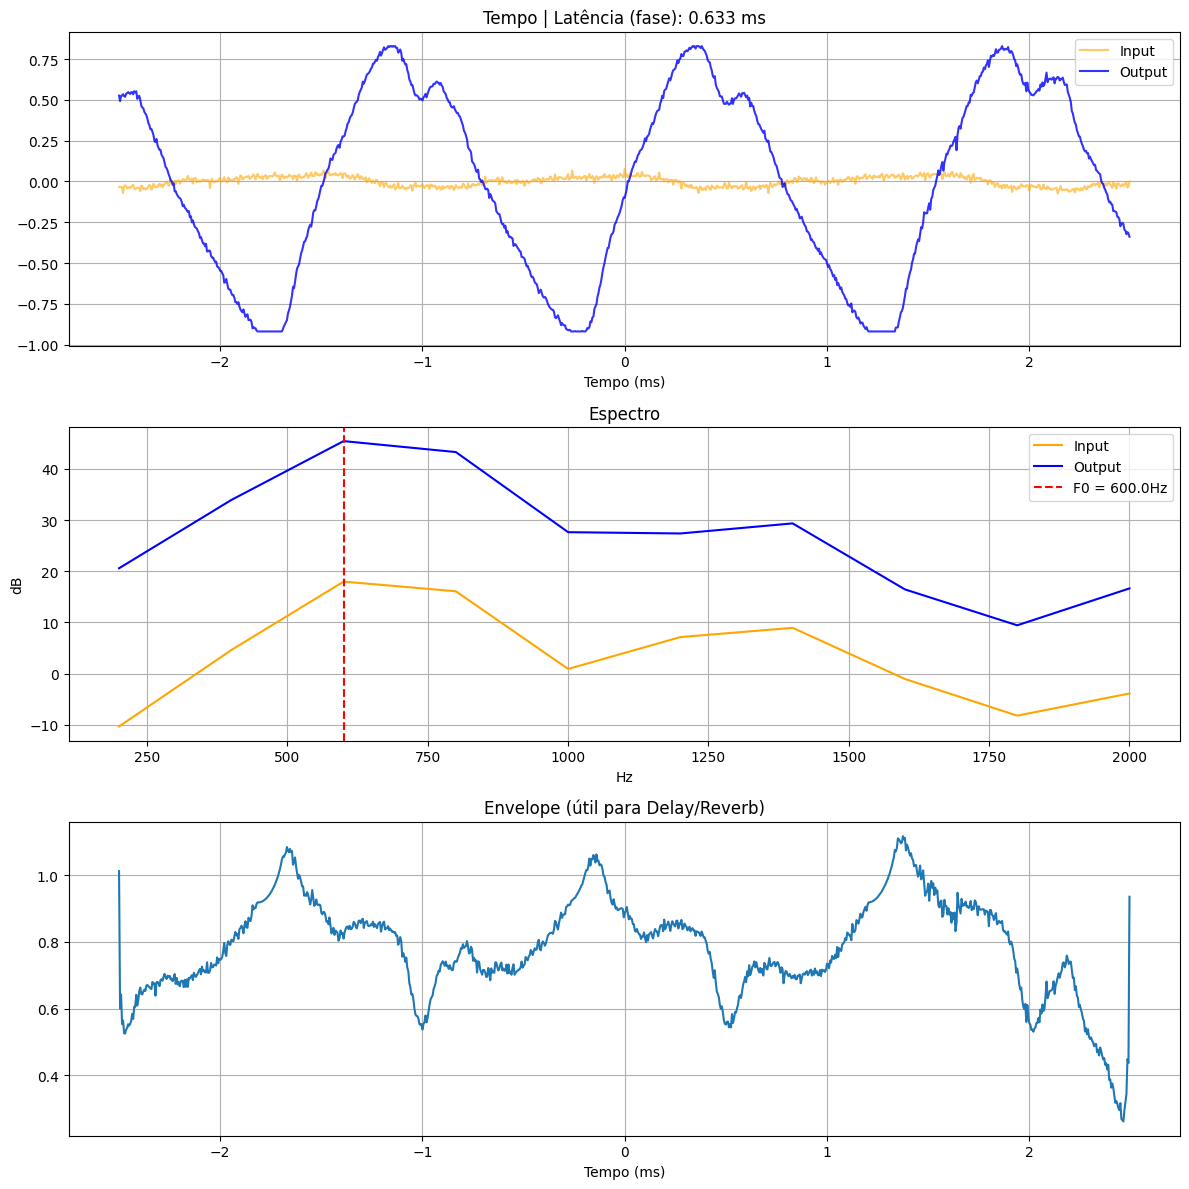

In [35]:
analisar_sinal('Processing/NotaDrive0.csv', 'Nota com Drive')

## 5. Acorde D (Ré) com efeitos
<img src='Processing/NotaAcorDe0.png' width=40%>


==================== Acorde ====================
fs = 200.0 kHz | N = 1000
MÉTRICAS:
Frequência Fundamental: 400.00 Hz
Ganho: 9.84 dB
Ganho Linear: 310.5%
Latência (por fase): 0.000 ms
THD: 36.78 %
Tempo de decaimento (~ -20dB): -2.50 ms
------------------------------------------------------------


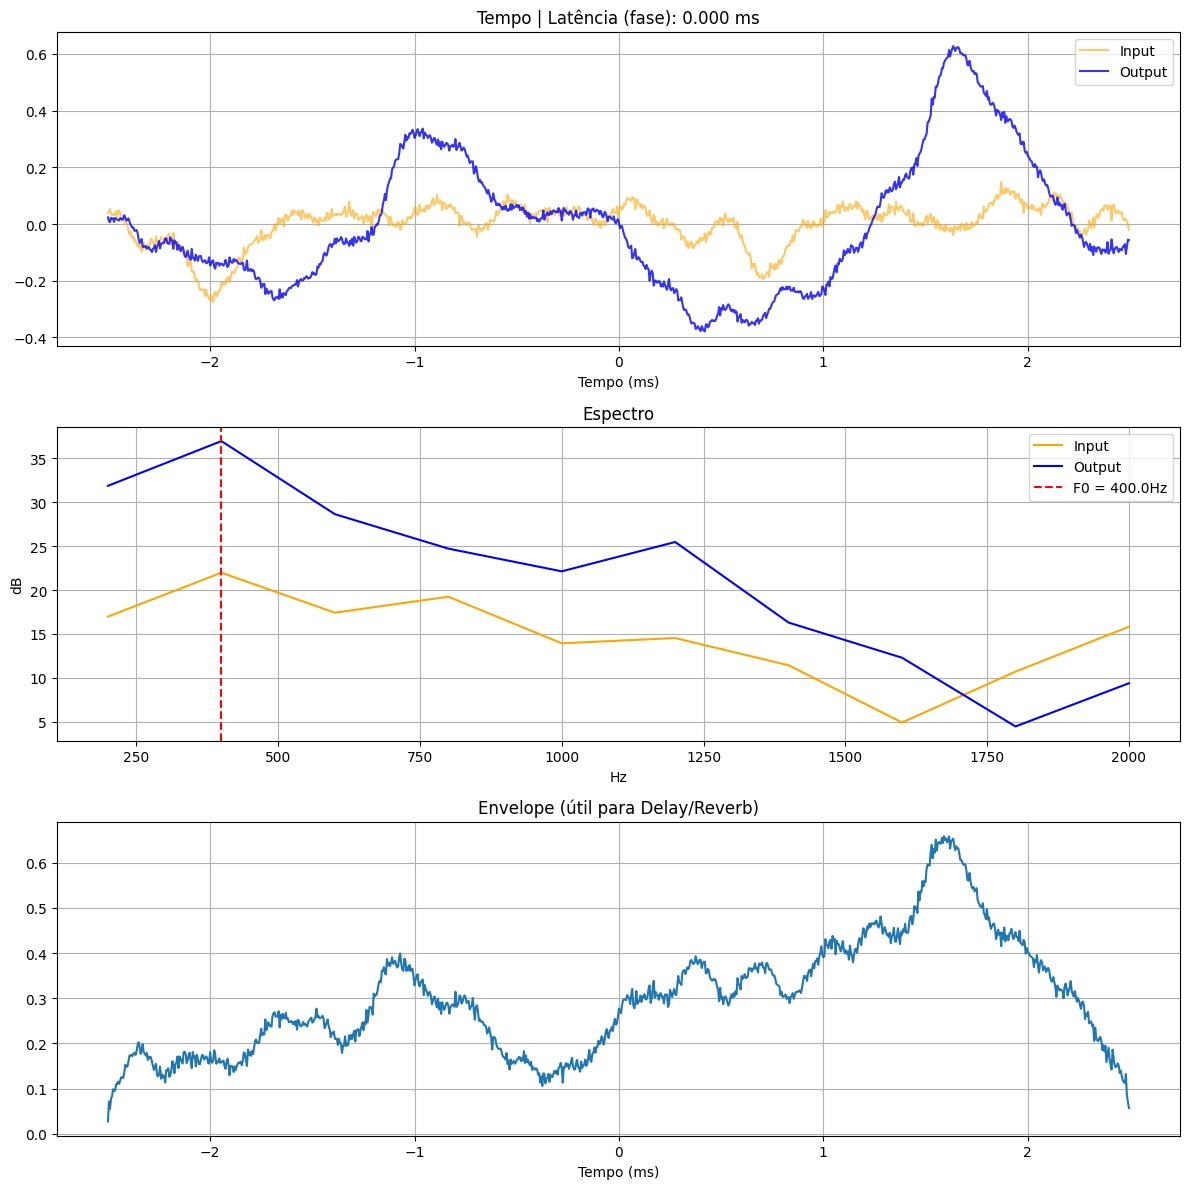

In [36]:
analisar_sinal('Processing/NotaAcorDe0.csv', 'Acorde')

# Resumo da Análise de Sinais

A tabela abaixo consolida as métricas extraídas do processamento de áudio em tempo real, com taxa de amostragem de 200 kHz.

| Preset | Freq. Fund. (Hz) | Ganho (dB) | Latência (ms) | THD (%) | Observação |
| --- | --- | --- | --- | --- | --- |
| **Limpo** | 600.00 | 11.30 | 0.659 | 36.52 | Referência base. |
| **Delay** | 600.00 | 12.54 | 0.609 | 14.59 | Leve aumento de ganho (repetições). |
| **Reverb** | 600.00 | 13.60 | 0.662 | 29.70 | Maior energia RMS. |
| **Drive** | 600.00 | **25.44** | 0.633 | 12.99 | **Ganho agressivo (+14dB).** |
| **Acorde** | 400.00 | 9.84 | *N/A* | 36.78 | Análise complexa (polifonia). |

### Conclusão Técnica

O sistema demonstrou uma performance de **latência ultrabaixa (~0.6 ms)**, imperceptível ao ouvido humano e ideal para aplicações em tempo real. O efeito de **Drive** comportou-se como esperado, elevando drasticamente o ganho (**25.44 dB**) para gerar saturação, enquanto os efeitos de tempo (Delay/Reverb) mantiveram a integridade do sinal com latência estável. O THD elevado no sinal limpo sugere uma possível saturação na entrada do ADC ou ruído de fundo, característico de circuitos de alto ganho. Para o delay e reverb ficarem muito perceptíveis, o salvamento de dados deve conter um espaço de tempo bem maior que 5ms, ficando para análises futuras.